# Exploratory Data Analysis: Mobile Money Adoption and Transaction Growth in Ghana

**Problem Statement.** Mobile money is now the main way money moves in Ghana, yet planners still rely on simple trend lines that miss the nonlinear, lagged drivers of adoption and growth. This project models who adopts mobile money and how national transaction value evolves.

**Objectives of this notebook.**
1. Understand each key variable on its own (univariate analysis).
2. See how the drivers relate to mobile money adoption and to each other (bivariate analysis).
3. Save the charts used in the interim report.

Two datasets are used: the pooled Global Findex records (individual level, target `adopts_mm`) and the monthly Bank of Ghana panel (national level, target `mm_value`).

## Setup (runs locally and on Google Colab)

On Colab this pulls the project data from GitHub. Locally it just uses the `data/` folder already in the repo. If you would rather upload the files by hand on Colab, run `from google.colab import files; files.upload()` instead of the clone.

In [1]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not os.path.exists('data/processed/findex_ghana_clean.csv'):
    import subprocess
    subprocess.run(['git','clone','-q','https://github.com/bcudjoe/mobile-money-ghana-forecasting.git'])
    os.chdir('mobile-money-ghana-forecasting')
print('Running on Colab' if IN_COLAB else 'Running locally')

Running locally


In [2]:
# libraries to read and handle the data
import numpy as np
import pandas as pd

# libraries for the charts
import matplotlib.pyplot as plt
import seaborn as sns

# show all columns and round floats to 2 dp
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid')

# where the figures are saved
FIG = 'outputs/figures/'
os.makedirs(FIG, exist_ok=True)

## Load the data

`findex` is one row per survey respondent (2,000 rows, two waves). `monthly` is one row per month (84 rows, 2019 to 2025).

In [3]:
findex = pd.read_csv('data/processed/findex_ghana_clean.csv')
monthly = pd.read_csv('data/processed/monthly_series_clean.csv', parse_dates=['date'])
print('findex :', findex.shape)
print('monthly:', monthly.shape)

findex : (2000, 15)
monthly: (84, 47)


## Preliminary Analysis of Features

In [4]:
findex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   resp_id               2000 non-null   int64  
 1   wave                  2000 non-null   int64  
 2   adopts_mm             2000 non-null   int64  
 3   has_account           2000 non-null   int64  
 4   made_digital_payment  2000 non-null   int64  
 5   income_quintile       2000 non-null   int64  
 6   education             2000 non-null   float64
 7   age                   2000 non-null   float64
 8   female                2000 non-null   int64  
 9   urban                 2000 non-null   int64  
 10  owns_mobile           2000 non-null   int64  
 11  has_internet          2000 non-null   int64  
 12  employed              2000 non-null   int64  
 13  borrowed_formal       2000 non-null   int64  
 14  saved_formal          2000 non-null   int64  
dtypes: float64(2), int64(

In [5]:
findex.head()

,resp_id,wave,adopts_mm,has_account,made_digital_payment,income_quintile,education,age,female,urban,owns_mobile,has_internet,employed,borrowed_formal,saved_formal
0,191902703,2021,1,1,1,5,3.00,34.00,0,0,1,1,1,0,1
1,143682454,2021,1,1,1,3,2.00,52.00,0,1,1,1,1,0,0
2,140671614,2021,0,1,1,3,2.00,15.00,1,1,1,1,1,1,0
3,191621240,2021,0,1,1,4,2.00,19.00,1,1,1,1,1,0,0
4,141873417,2021,0,1,1,3,2.00,29.00,1,0,1,1,0,0,0


In [6]:
findex.describe().T

,count,mean,std,min,25%,50%,75%,max
resp_id,2000.00,160411124.51,29015813.40,111146058.00,135014155.75,160116042.50,185334972.00,211052510.00
wave,2000.00,2023.00,2.00,2021.00,2021.00,2023.00,2025.00,2025.00
adopts_mm,2000.00,0.75,0.43,0.00,0.00,1.00,1.00,1.00
has_account,2000.00,0.80,0.40,0.00,1.00,1.00,1.00,1.00
made_digital_payment,2000.00,0.78,0.41,0.00,1.00,1.00,1.00,1.00
income_quintile,2000.00,3.28,1.43,1.00,2.00,3.00,5.00,5.00
education,2000.00,1.81,0.58,1.00,1.00,2.00,2.00,3.00
age,2000.00,32.36,12.67,15.00,23.00,30.00,38.00,100.00
female,2000.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
urban,2000.00,0.45,0.50,0.00,0.00,0.00,1.00,1.00


In [7]:
# missing values after cleaning
print('findex missing:', int(findex.isna().sum().sum()))
print('monthly missing (core columns):', int(monthly[['mm_value','agent_density','account_ownership']].isna().sum().sum()))

findex missing: 0
monthly missing (core columns): 0


### Observations:
- The Findex table has 2,000 respondents and 15 columns, with no missing values after cleaning.
- `adopts_mm` is the binary target: 1 if the respondent uses mobile money, 0 otherwise.
- Most predictors are binary (0/1); `income_quintile` (1 to 5), `education` (1 to 3) and `age` carry more levels.
- The monthly panel is complete across all 84 months, including the interpolated `agent_density` and `account_ownership`.

## EDA Utility Functions

Defined once and reused, in the same spirit as a reusable plotting toolkit. `histogram_boxplot` for numeric variables, `labeled_barplot` for categories, and `adoption_rate_barplot` for the bivariate view against the target.

In [8]:
def histogram_boxplot(df, feature, figsize=(9, 5), kde=False, bins=None, fname=None):
    """Boxplot on top of a histogram, sharing the x-axis, with mean and median marked."""
    f, (ax_box, ax_hist) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={'height_ratios': (0.25, 0.75)}, figsize=figsize)
    sns.boxplot(data=df, x=feature, ax=ax_box, showmeans=True, color='violet')
    if bins:
        sns.histplot(data=df, x=feature, kde=kde, ax=ax_hist, bins=bins, color='#2E74B5')
    else:
        sns.histplot(data=df, x=feature, kde=kde, ax=ax_hist, color='#2E74B5')
    ax_hist.axvline(df[feature].mean(), color='green', linestyle='--', label='mean')
    ax_hist.axvline(df[feature].median(), color='black', linestyle='-', label='median')
    ax_hist.legend()
    ax_box.set(xlabel='')
    plt.tight_layout()
    if fname: plt.savefig(FIG + fname)
    plt.show()


def labeled_barplot(df, feature, perc=True, figsize=(7, 4), fname=None):
    """Count plot with the count or percentage printed on each bar."""
    total = len(df[feature])
    plt.figure(figsize=figsize)
    order = df[feature].value_counts().index
    ax = sns.countplot(data=df, x=feature, order=order, color='#2E74B5')
    for p in ax.patches:
        pct = '{:.1f}%'.format(100 * p.get_height() / total)
        label = pct if perc else '{:.0f}'.format(p.get_height())
        ax.annotate(label, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    if fname: plt.savefig(FIG + fname)
    plt.show()


def adoption_rate_barplot(df, feature, target='adopts_mm', figsize=(6, 4), labels=None, fname=None):
    """Mean of the target (as a %) for each level of a categorical feature."""
    rate = df.groupby(feature)[target].mean() * 100
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=rate.index.astype(str), y=rate.values, color='#1E7A46')
    if labels: ax.set_xticklabels(labels)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 1, '{:.1f}%'.format(v), ha='center', fontsize=9)
    ax.set_ylim(0, 100); ax.set_ylabel('Adoption rate (%)')
    plt.tight_layout()
    if fname: plt.savefig(FIG + fname)
    plt.show()
    return rate.round(1)

# Univariate Analysis

## Analysis of "adopts_mm" (target)

adopts_mm
1    1496
0     504
Name: count, dtype: int64


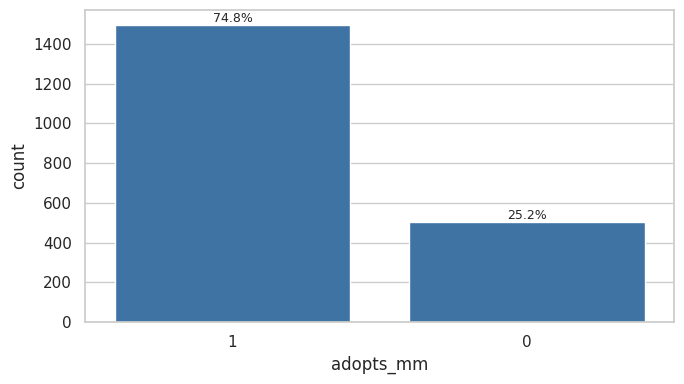

In [9]:
print(findex['adopts_mm'].value_counts())
labeled_barplot(findex, 'adopts_mm', perc=True, fname='eda_adopts_mm.png')

### Observations on "adopts_mm":
- Adoption is the target for the RQ1 model, coded 1 for users and 0 for non-users.
- Roughly three quarters of the pooled sample use mobile money, so the classes are imbalanced but not severely.
- Because the two waves are pooled, this share sits between the 2021 and 2025 rates examined later.

## Analysis of "age"

count   2000.00
mean      32.40
std       12.70
min       15.00
25%       23.00
50%       30.00
75%       38.00
max      100.00
Name: age, dtype: float64


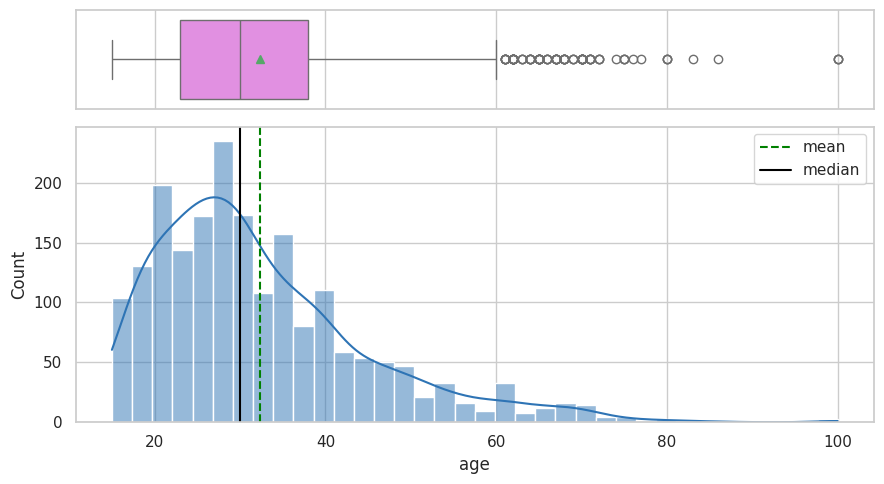

In [10]:
print(findex['age'].describe().round(1))
histogram_boxplot(findex, 'age', kde=True, fname='eda_age.png')

### Observations on "age":
- Age is roughly mid-30s on average and mildly right-skewed, with a tail of older respondents.
- The mean and median sit close together, so no aggressive transformation is needed.
- Age is later checked against adoption, where it shows only a weak negative association.

## Analysis of "income_quintile"

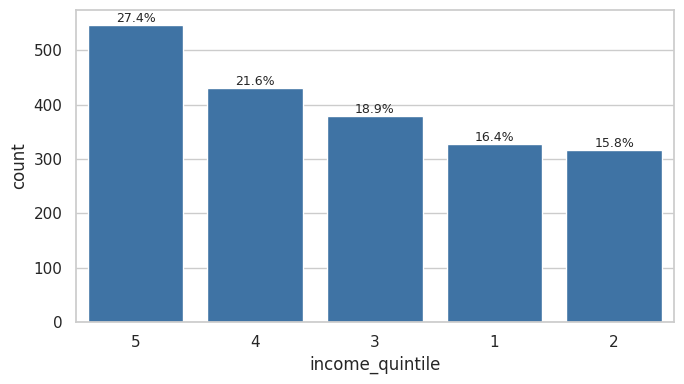

In [11]:
labeled_barplot(findex, 'income_quintile', perc=True, fname='eda_income_quintile.png')

### Observations on "income_quintile":
- The five income groups are fairly evenly represented, as expected for a within-country quintile split.
- Income is one of the clearer adoption gradients in the bivariate section.

## Analysis of "education"

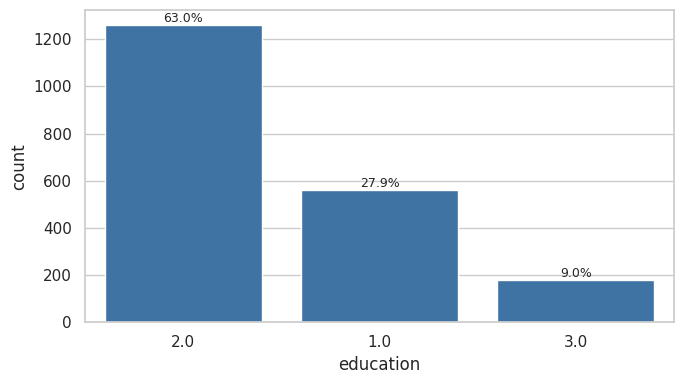

In [12]:
labeled_barplot(findex, 'education', perc=True, fname='eda_education.png')

### Observations on "education":
- Education is coded 1 (primary or less), 2 (secondary) and 3 (tertiary).
- Secondary is the most common level; tertiary is the smallest group but has the highest adoption.

## Analysis of "mm_value" (monthly transaction value)

count       84.00
mean    147447.00
std     122096.00
min      20919.00
25%      57858.00
50%      88970.00
75%     200243.00
max     518397.00
Name: mm_value, dtype: float64


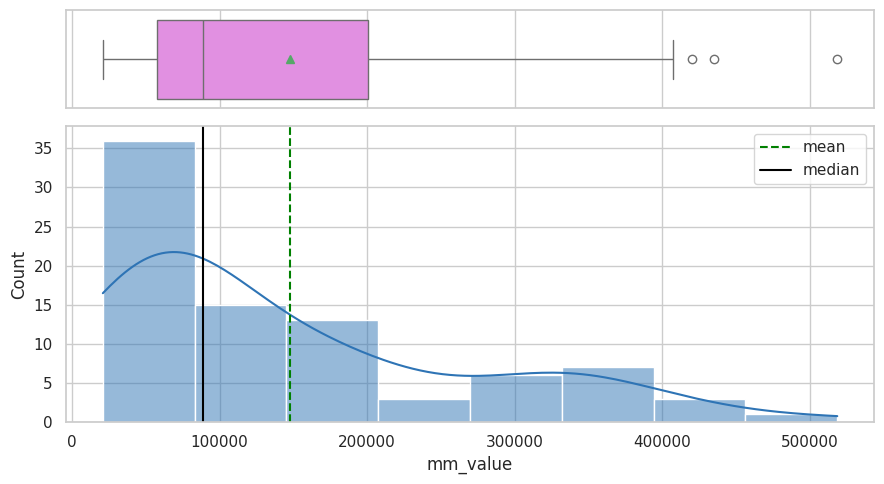

In [13]:
print(monthly['mm_value'].describe().round(0))
histogram_boxplot(monthly, 'mm_value', kde=True, fname='eda_mm_value.png')

### Observations on "mm_value":
- Monthly transaction value ranges from about GH¢20,900m to GH¢518,400m and is right-skewed.
- The long right tail reflects the steep growth after 2020 rather than outliers to be removed.
- This is the target for the RQ2 and RQ3 forecasting models.

## Analysis of "agent_density"

count     84.00
mean    2047.60
std      568.10
min      980.20
25%     1650.20
50%     2108.50
75%     2455.00
max     2987.40
Name: agent_density, dtype: float64


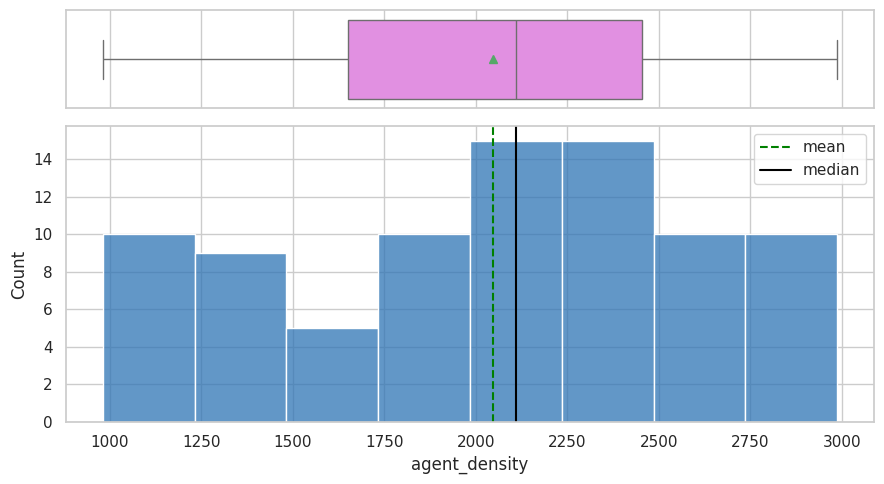

In [14]:
print(monthly['agent_density'].describe().round(1))
histogram_boxplot(monthly, 'agent_density', fname='eda_agent_density.png')

### Observations on "agent_density":
- Agent density rises steadily from about 1,000 to over 2,300 agents per 100,000 adults across the window.
- It is a slow-moving structural variable, so it carries trend rather than month-to-month noise.

### Observations on Univariate Analysis
- The individual predictors are clean and on sensible scales; no variable needs dropping.
- The monthly targets are right-skewed with genuine growth, which favours lag-based features over a plain linear trend.
- Adoption is common but uneven, which the bivariate analysis unpacks next.

# Bivariate Analysis

## Correlation Heatmap of Monthly Predictors

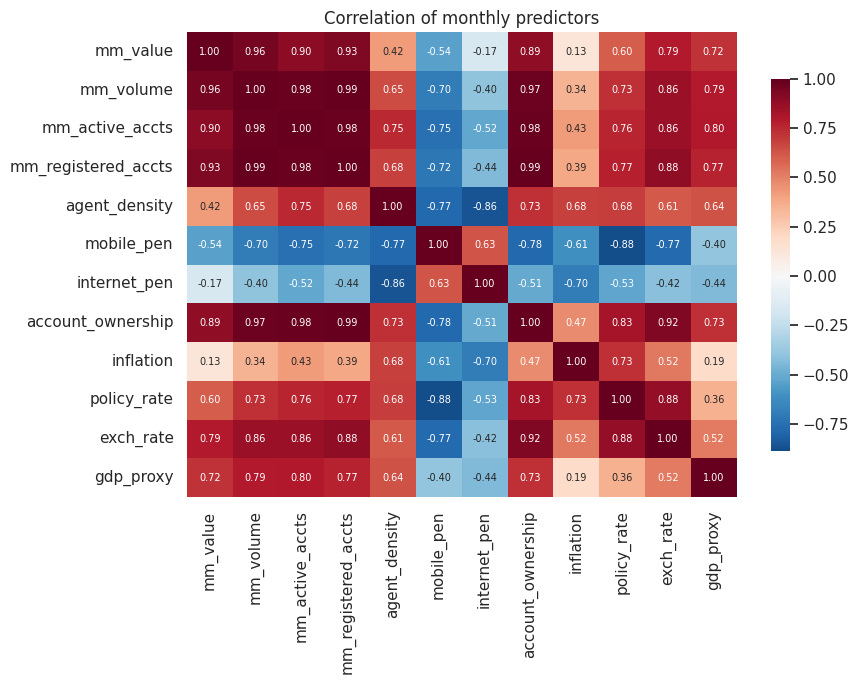

In [15]:
num_cols = ['mm_value','mm_volume','mm_active_accts','mm_registered_accts','agent_density',
            'mobile_pen','internet_pen','account_ownership','inflation','policy_rate','exch_rate','gdp_proxy']
plt.figure(figsize=(9, 7))
sns.heatmap(monthly[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            annot_kws={'size':7}, cbar_kws={'shrink':0.8})
plt.title('Correlation of monthly predictors')
plt.tight_layout(); plt.savefig(FIG + 'eda_corr_heatmap.png'); plt.show()

### Observations on Heatmap:
- Value, volume, and the account measures are strongly positively correlated, which is expected.
- This collinearity means a plain linear model would be unstable, so lag features and tree-based models are preferred for forecasting.
- Inflation and the exchange rate move together and both track the post-2022 period.

## Adoption by Categorical Drivers (bivariate against the target)

Adoption by income quintile (%):


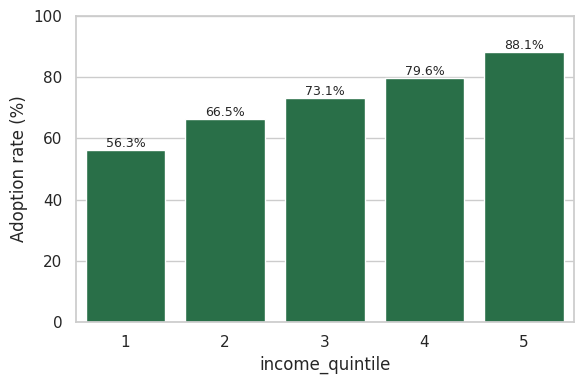

income_quintile
1   56.30
2   66.50
3   73.10
4   79.60
5   88.10
Name: adopts_mm, dtype: float64


In [16]:
print('Adoption by income quintile (%):')
print(adoption_rate_barplot(findex, 'income_quintile', fname='eda_adopt_by_income.png'))

Adoption by education (%):


/sessions/admiring-happy-franklin/tmp/ipykernel_46/3387538274.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  if labels: ax.set_xticklabels(labels)


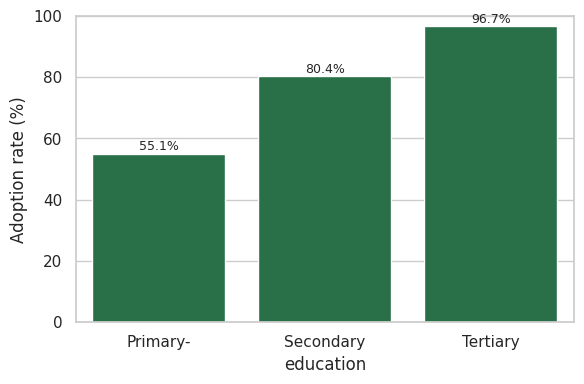

education
1.00   55.10
2.00   80.40
3.00   96.70
Name: adopts_mm, dtype: float64


In [17]:
print('Adoption by education (%):')
print(adoption_rate_barplot(findex, 'education', labels=['Primary-','Secondary','Tertiary'], fname='eda_adopt_by_education.png'))

In [18]:
print('Adoption by residence and gender (%):')
print('urban :', round(findex[findex.urban==1].adopts_mm.mean()*100,1))
print('rural :', round(findex[findex.urban==0].adopts_mm.mean()*100,1))
print('female:', round(findex[findex.female==1].adopts_mm.mean()*100,1))
print('male  :', round(findex[findex.female==0].adopts_mm.mean()*100,1))

Adoption by residence and gender (%):
urban : 69.3
rural : 79.3
female: 70.7
male  : 78.5


### Observations on Categorical Bivariate Analysis:
- Adoption rises cleanly with income, from about 56% in the poorest quintile to 88% in the richest.
- Education matters even more: 55% for primary or less, 80% for secondary, and 97% for tertiary.
- There is a gender gap of roughly 8 percentage points (male 78.5% vs female 70.7%).
- Urban respondents show slightly lower adoption than rural ones here (69.3% vs 79.3%), which is worth probing further, since mobile money often fills gaps where bank branches are scarce.

## Adoption vs Age (numerical bivariate)

/sessions/admiring-happy-franklin/tmp/ipykernel_46/2337586131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=findex, x='adopts_mm', y='age', showmeans=True, palette=['#E08A1E','#1E7A46'])


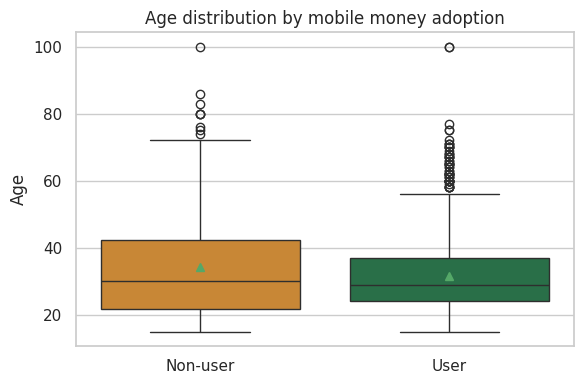

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=findex, x='adopts_mm', y='age', showmeans=True, palette=['#E08A1E','#1E7A46'])
plt.xticks([0,1], ['Non-user','User']); plt.xlabel(''); plt.ylabel('Age')
plt.title('Age distribution by mobile money adoption')
plt.tight_layout(); plt.savefig(FIG + 'eda_age_by_adoption.png'); plt.show()

### Observations on numerical Bivariate Analysis:
- The age distributions of users and non-users overlap heavily, so age on its own is a weak separator.
- Users are, if anything, slightly younger on average, consistent with the small negative coefficient in the RQ1 model.

## Transaction Value over Time (with the E-Levy)

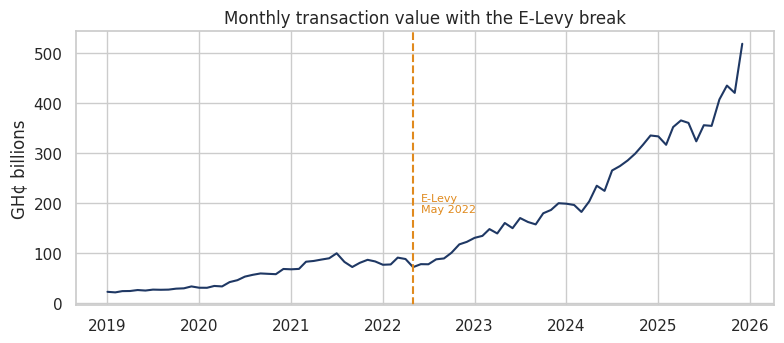

In [20]:
plt.figure(figsize=(8, 3.6))
sns.lineplot(data=monthly, x='date', y=monthly['mm_value']/1000, color='#1F3864')
plt.axvline(pd.Timestamp('2022-05-01'), color='#E08A1E', linestyle='--')
plt.text(pd.Timestamp('2022-06-01'), monthly['mm_value'].max()/1000*0.35, 'E-Levy\nMay 2022', color='#E08A1E', fontsize=8)
plt.ylabel('GH¢ billions'); plt.xlabel('')
plt.title('Monthly transaction value with the E-Levy break')
plt.tight_layout(); plt.savefig(FIG + 'eda_mm_value_time.png'); plt.show()

### Observations:
- Value grows steeply through 2020 to 2021, flattens around the May 2022 E-Levy, then resumes rising.
- This visible break is why an E-Levy indicator is added as a feature before forecasting.

## Summary
- The strongest adoption signals are income, education and prior financial behaviour, with a clear gender gap.
- The monthly targets are trending and collinear, so the forecasting models lean on lag features and a structural-break flag.
- All figures are saved under `outputs/figures/` for the interim report.